# 03. Аудит validation split

Цель — проверить не размер validation, а переносимость схемы разбиения. Одна и
та же names-only lexical CatBoost обучается на нескольких splits. Hard-negative
оценка намеренно вынесена в следующий notebook и не смешивается с основной AP.

In [1]:
import importlib.util
import subprocess
import sys

required_packages = {
    'rapidfuzz': 'rapidfuzz>=3.12,<4',
    'catboost': 'catboost==1.2.8',
    'sklearn': 'scikit-learn>=1.5,<2',
    'pyarrow': 'pyarrow>=17,<22',
    'matplotlib': 'matplotlib>=3.9,<4',
    'seaborn': 'seaborn>=0.13,<0.14',
    'tabulate': 'tabulate>=0.9,<1',
}
missing = [package for module, package in required_packages.items()
           if importlib.util.find_spec(module) is None]
if missing:
    print('Installing missing notebook dependencies:', missing)
    subprocess.run([sys.executable, '-m', 'pip', 'install', *missing], check=True)
    print('Dependencies installed. Restart the kernel once, then run all cells again.')
else:
    print('All notebook dependencies are available.')


All notebook dependencies are available.


In [2]:
from pathlib import Path
import json, sys, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / 'src').is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.validation_audit import (
    build_split_scenarios, evaluate_split, lexical_pair_table, prepare_items,
    representation_overlap, reports_to_frame, save_json,
)

DATA_DIR = ROOT / 'data'
OUTPUT_DIR = ROOT / 'reports' / 'validation_split_audit'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
VALIDATION_FRACTION = 0.15
SEEDS = (13, 42, 77, 2026)
CATBOOST_ITERATIONS = 1200
CATBOOST_DEPTH = 8


## 1. Подготовка параллельных представлений

In [3]:
matches = pd.read_parquet(DATA_DIR/'matches.parquet', columns=['id1','id2','target'])
started = time.perf_counter()
prepared_items_path = OUTPUT_DIR/'prepared_items.parquet'
pair_features_path = OUTPUT_DIR/'pair_audit_features.parquet'
if prepared_items_path.exists() and pair_features_path.exists():
    items = pd.read_parquet(prepared_items_path)
    pairs = pd.read_parquet(pair_features_path)
    print('Reusing prepared audit tables from', OUTPUT_DIR)
else:
    items_raw = pd.read_parquet(DATA_DIR/'items_human.parquet', columns=['id','name','attributes','category'])
    items = prepare_items(items_raw)
    pairs = lexical_pair_table(items, matches)
    items.drop(columns=['attributes_parsed']).to_parquet(prepared_items_path, index=False)
    pairs.to_parquet(pair_features_path, index=False)
print(f'Prepared {len(items):,} items and {len(pairs):,} pairs in {(time.perf_counter()-started)/60:.1f} min')
display(pairs.groupby('category').target.agg(['size','mean']).rename(columns={'mean':'positive_rate'}))


Reusing prepared audit tables from C:\Users\Professional\product_matching\reports\validation_split_audit
Prepared 711,304 items and 365,654 pairs in 0.1 min


,size,positive_rate
category,,
Автотовары,19010,0.174961
Аптека,18285,0.072628
Бытовая техника,17814,0.359493
Бытовая химия,17436,0.469316
Галантерея и аксессуары,17984,0.167649
Детские товары,17561,0.561984
Дом и сад,17574,0.262206
Канцелярские товары,17435,0.338572
Красота и гигиена,17286,0.363473


## 2. Несколько seed и альтернативные grouped splits

In [4]:
scenarios = build_split_scenarios(items, matches, VALIDATION_FRACTION, SEEDS)
pd.DataFrame([{
    'split': split.name, 'train_pairs': int(split.train_mask.sum()),
    'validation_pairs': int(split.valid_mask.sum()), 'notes': split.notes,
} for split in scenarios])


,split,train_pairs,validation_pairs,notes
0,component_seed_13,310704,54950,Exact reproduction of the existing connected-c...
1,component_seed_42,310767,54887,Exact reproduction of the existing connected-c...
2,component_seed_77,310856,54798,Exact reproduction of the existing connected-c...
3,component_seed_2026,310277,55377,Exact reproduction of the existing connected-c...
4,exact_normalized_name_holdout,314973,50681,Pair components merged by exact category + nor...
5,brand_model_family_holdout,311978,53676,Pair components merged by conservative categor...


## 3. Одинаковая lexical CatBoost на каждом split

Reusing completed component_seed_13: 0.514904028384206
Reusing completed component_seed_42: 0.5044499172321768
Reusing completed component_seed_77: 0.5000186624029948
Reusing completed component_seed_2026: 0.49816709100012774
Reusing completed exact_normalized_name_holdout: 0.5031706949618785
Reusing completed brand_model_family_holdout: 0.5086979345075973


,split,notes,train_pairs,validation_pairs,validation_fraction,train_positive_rate,validation_positive_rate,overlapping_item_ids,macro_average_precision,overall_average_precision,best_iteration,catboost_backend
0,component_seed_13,Exact reproduction of the existing connected-c...,310704,54950,0.150279,0.256466,0.258508,0,0.514904,0.600664,1199,CPU
5,brand_model_family_holdout,Pair components merged by conservative categor...,311978,53676,0.146795,0.256422,0.258812,0,0.508698,0.596796,1199,CPU
1,component_seed_42,Exact reproduction of the existing connected-c...,310767,54887,0.150106,0.256662,0.257402,0,0.504450,0.596221,1192,CPU
4,exact_normalized_name_holdout,Pair components merged by exact category + nor...,314973,50681,0.138604,0.255235,0.266333,0,0.503171,0.600905,1199,CPU
2,component_seed_77,Exact reproduction of the existing connected-c...,310856,54798,0.149863,0.257109,0.254863,0,0.500019,0.589266,1188,CPU
3,component_seed_2026,Exact reproduction of the existing connected-c...,310277,55377,0.151446,0.257167,0.254564,0,0.498167,0.580493,1198,CPU


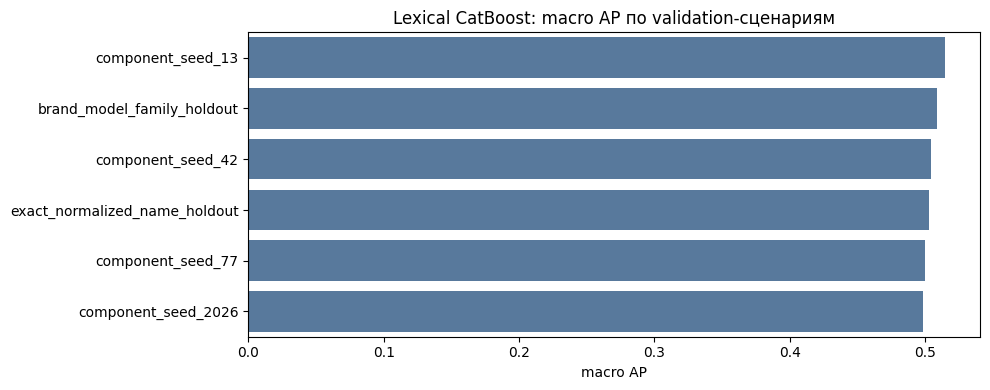

In [5]:
reports = []
overlaps = []
cached_overlap_path = OUTPUT_DIR/'representation_overlap.csv'
cached_overlaps = pd.read_csv(cached_overlap_path) if cached_overlap_path.exists() else pd.DataFrame()
for split in scenarios:
    report_path = OUTPUT_DIR/f'{split.name}_report.json'
    predictions_path = OUTPUT_DIR/f'{split.name}_predictions.parquet'
    model_path = OUTPUT_DIR/f'{split.name}.cbm'
    if report_path.exists() and predictions_path.exists() and model_path.exists():
        report = json.loads(report_path.read_text(encoding='utf-8'))
        reports.append(report)
        if not cached_overlaps.empty:
            overlaps.append(cached_overlaps[cached_overlaps.split.eq(split.name)].copy())
        print(f'Reusing completed {split.name}:', report['macro_average_precision'])
        continue
    print(f'Running {split.name} ...', flush=True)
    report, predictions, model = evaluate_split(
        pairs, split, iterations=CATBOOST_ITERATIONS, depth=CATBOOST_DEPTH,
    )
    reports.append(report)
    predictions.to_parquet(predictions_path, index=False)
    model.save_model(model_path)
    overlap = representation_overlap(items, pairs, split)
    overlap.insert(0, 'split', split.name)
    overlaps.append(overlap)
    save_json(report_path, report)
    print(split.name, report['macro_average_precision'])

comparison = reports_to_frame(reports).sort_values('macro_average_precision', ascending=False)
overlap_table = pd.concat(overlaps, ignore_index=True)
comparison.to_csv(OUTPUT_DIR/'split_comparison.csv', index=False)
overlap_table.to_csv(OUTPUT_DIR/'representation_overlap.csv', index=False)
display(comparison)
figure, axis = plt.subplots(figsize=(10, 4))
sns.barplot(data=comparison, x='macro_average_precision', y='split', ax=axis, color='#4C78A8')
axis.set(title='Lexical CatBoost: macro AP по validation-сценариям', xlabel='macro AP', ylabel='')
figure.tight_layout(); figure.savefig(OUTPUT_DIR/'split_macro_ap.png', dpi=160, bbox_inches='tight')
plt.show()


## 4. Насколько содержательные представления пересекаются между train и validation

representation,brand,family_signature,model_or_id,normalized_name,seller
split,,,,,
brand_model_family_holdout,0.792678,0.000000,0.063968,0.125614,0.212121
component_seed_13,0.793087,0.084239,0.101560,0.130907,0.129032
component_seed_2026,0.792641,0.083727,0.103799,0.130475,0.176471
component_seed_42,0.795945,0.086683,0.105306,0.130017,0.166667
component_seed_77,0.798009,0.082019,0.101618,0.130946,0.184211
exact_normalized_name_holdout,0.773797,0.061749,0.087099,0.002685,0.400000


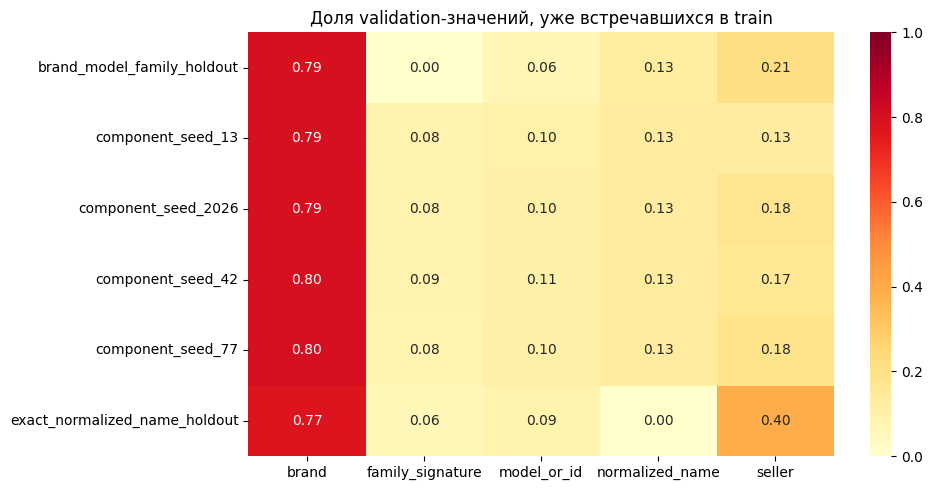

In [6]:
overlap_pivot = overlap_table.pivot(index='split', columns='representation', values='validation_seen_share')
display(overlap_pivot)
figure, axis = plt.subplots(figsize=(10, 5))
sns.heatmap(overlap_pivot, annot=True, fmt='.2f', vmin=0, vmax=1, cmap='YlOrRd', ax=axis)
axis.set(title='Доля validation-значений, уже встречавшихся в train', xlabel='', ylabel='')
figure.tight_layout(); figure.savefig(OUTPUT_DIR/'representation_overlap.png', dpi=160, bbox_inches='tight')
plt.show()


## 5. Автоматический черновик отчёта

In [7]:
best_stress = comparison.sort_values('macro_average_precision').iloc[0]
iid = comparison[comparison.split.eq('component_seed_42')].iloc[0]
lines = [
    '# Результаты аудита validation split', '',
    f'- Текущий component seed 42: macro AP `{iid.macro_average_precision:.6f}`.',
    f'- Самый сложный проверенный split: `{best_stress.split}`, macro AP `{best_stress.macro_average_precision:.6f}`.',
    '', '## Полная таблица', '', comparison.to_markdown(index=False), '',
    'Это автоматически созданный отчёт. Интерпретацию и финальную рекомендацию нужно перенести в `docs/validation-split-audit.md` после просмотра overlaps и ошибок.'
]
(OUTPUT_DIR/'report.md').write_text('\n'.join(lines), encoding='utf-8')
save_json(OUTPUT_DIR/'manifest.json', {'status':'complete','seeds':SEEDS,'reports':reports})
(OUTPUT_DIR/'COMPLETED').write_text('ok\n', encoding='utf-8')
print(OUTPUT_DIR/'report.md')


C:\Users\Professional\product_matching\reports\validation_split_audit\report.md
